In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset.csv"
df = pd.read_csv(path)

print("Loaded successfully:", df.shape)
df.head()

Loaded successfully: (48536, 21)


,Patient_ID,Age,Sex,Family_History,HTT_CAG_Repeat_Length,Motor_Symptoms,Cognitive_Decline,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,...,HTT_Gene_Expression_Level,Protein_Aggregation_Level,Random_Protein_Sequence,Random_Gene_Sequence,Disease_Stage,Gene/Factor,Chromosome_Location,Function,Effect,Category
0,b2a49170-8561-4665-9371-2240b55dd87a,31,Male,No,67,Moderate,Severe,8.80,3.20,94,...,1.67,0.58,DAHKIRSPMRVGPHYYAQCDNNDTGSDKEHWLKTEAAPMTMDRTVE...,GCCAGCAGCGCCCGAGCGTATGAGGTATATGGATTGGACATTGGGC...,Middle,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
1,f5fae45d-8718-41c4-a957-6928f79f3c8e,33,Female,Yes,38,Severe,Moderate,3.24,5.98,50,...,0.18,0.30,PANGFWYHNCLRFWNIPPYVMEGFPLADITEVHKWRVSGFMCWETQ...,AGTTTTCAGTGAGACTCTTCCCCAAAAGCCTCCACTACGACAGTGT...,Pre-Symptomatic,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
2,66ab0567-050b-4d56-9ec4-b676309899a6,69,Male,Yes,37,Severe,Moderate,1.01,2.82,69,...,0.90,1.04,NWHEGHGASTWKATMVAWCLMVQHAVTWKEGNTRCREMSCMNFTQL...,TATACCACCAGTGGGAAGAGTAACGATTTTGGAGCGCCCCGAGTCC...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
3,996a48e4-e841-418f-a539-5a7a86cd815d,66,Male,Yes,50,Mild,Severe,3.21,6.77,76,...,1.16,1.87,KCVQYIQATQMLVQSWGQRNPIMQSSEPDRAHDYESGTPKTYTYML...,GCGCGACCGACCAAAGGACCCATGGTGGTGATCTGTCATTGGATTC...,Pre-Symptomatic,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
4,d45c7ca8-7125-4aaa-8018-5bbc60d35a1f,43,Female,Yes,48,Moderate,Mild,2.31,7.53,70,...,1.85,2.94,DQPGNMTRQNKNHCMWRAKRPTKHPGHKPGEIDKEKSEQNDADSSA...,GGGACCGCGGTTCTAGAAGAGAGGTTCTCTGACCGCCGAAGGATTC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48536 entries, 0 to 48535
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 48536 non-null  object 
 1   Age                        48536 non-null  int64  
 2   Sex                        48536 non-null  object 
 3   Family_History             48536 non-null  object 
 4   HTT_CAG_Repeat_Length      48536 non-null  int64  
 5   Motor_Symptoms             48536 non-null  object 
 6   Cognitive_Decline          36417 non-null  object 
 7   Chorea_Score               48536 non-null  float64
 8   Brain_Volume_Loss          48536 non-null  float64
 9   Functional_Capacity        48536 non-null  int64  
 10  Gene_Mutation_Type         48536 non-null  object 
 11  HTT_Gene_Expression_Level  48536 non-null  float64
 12  Protein_Aggregation_Level  48536 non-null  float64
 13  Random_Protein_Sequence    48536 non-null  obj

In [6]:
df['Cognitive_Decline'] = (
    df['Cognitive_Decline']
    .astype(object)
    .replace([None, np.nan, '', ' '], 'None')
)


In [7]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

print(missing_df)


                           Missing Values  Percentage
Patient_ID                              0         0.0
Age                                     0         0.0
Sex                                     0         0.0
Family_History                          0         0.0
HTT_CAG_Repeat_Length                   0         0.0
Motor_Symptoms                          0         0.0
Cognitive_Decline                       0         0.0
Chorea_Score                            0         0.0
Brain_Volume_Loss                       0         0.0
Functional_Capacity                     0         0.0
Gene_Mutation_Type                      0         0.0
HTT_Gene_Expression_Level               0         0.0
Protein_Aggregation_Level               0         0.0
Random_Protein_Sequence                 0         0.0
Random_Gene_Sequence                    0         0.0
Disease_Stage                           0         0.0
Gene/Factor                             0         0.0
Chromosome_Location         

In [8]:
df['Cognitive_Decline'].unique()


array(['Severe', 'Moderate', 'Mild', 'None'], dtype=object)

In [9]:
for col in df.columns:
    if df[col].dtype in ["int64", "float64"]:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipython-input-1656150649.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-1656150649.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [10]:
df.describe()


,Age,HTT_CAG_Repeat_Length,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,HTT_Gene_Expression_Level,Protein_Aggregation_Level
count,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000
mean,55.070566,57.516606,4.994399,5.261030,50.354829,1.301060,2.546519
std,14.762154,13.264153,2.897327,1.872995,29.189697,0.691657,1.414745
min,30.000000,35.000000,0.000000,2.000000,0.000000,0.100000,0.100000
25%,42.000000,46.000000,2.480000,3.640000,25.000000,0.700000,1.330000
50%,55.000000,58.000000,4.980000,5.280000,50.000000,1.300000,2.540000
75%,68.000000,69.000000,7.500000,6.880000,76.000000,1.900000,3.770000
max,80.000000,80.000000,10.000000,8.500000,100.000000,2.500000,5.000000


In [11]:
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicates: 0


In [12]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df[numerical_cols] < (Q1 - 1.5 * IQR)) | \
               (df[numerical_cols] > (Q3 + 1.5 * IQR))
total_outlier_rows = outlier_mask.any(axis=1).sum()

if total_outlier_rows == 0:
    print("No outliers")
else:
    print(f"Outliers detected in {total_outlier_rows} rows")

No outliers


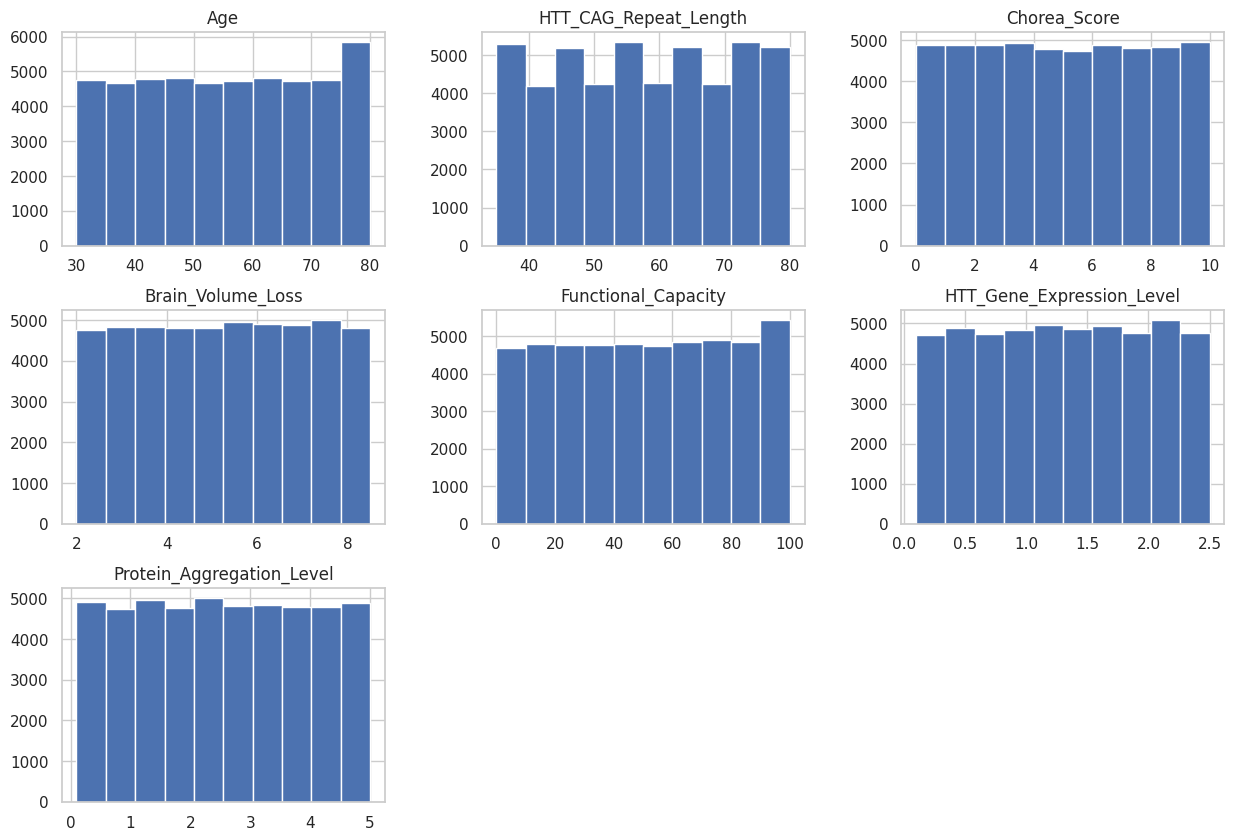

In [13]:
df[numerical_cols].hist(figsize=(15, 10))
plt.show()


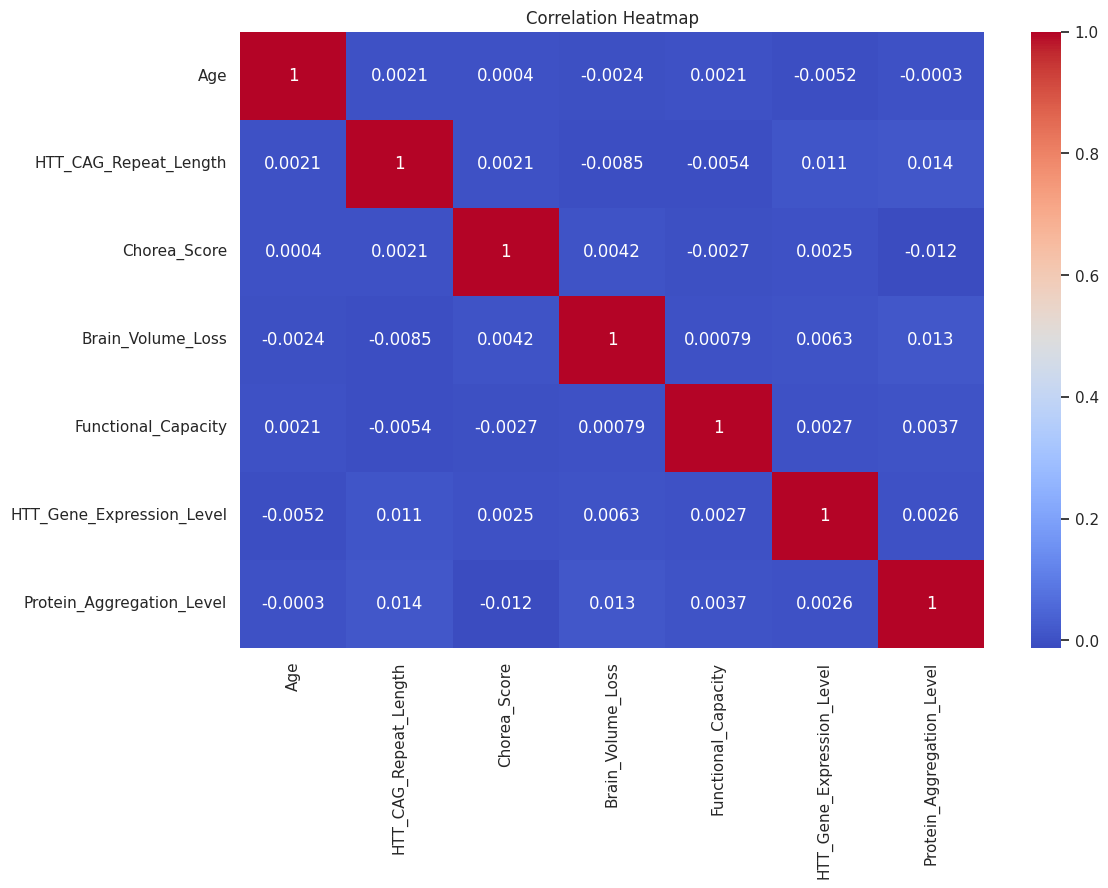

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# One hot Encoding
df = pd.get_dummies(df, drop_first=True)


In [15]:
df.to_csv("Huntington_Disease_Dataset_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")


KeyboardInterrupt: 

In [ ]:
# Example path in your Google Drive
file_path = '/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset_Cleaned.csv'

# Save DataFrame
df.to_csv(file_path, index=False)
print("Saved to Google Drive:", file_path)
